# Differentiable Predictive Control of a Two-Tank System

A coupled two-tank rig sits in a controls lab: water is pumped into the top tank,
drains into the bottom tank through an orifice, and drains again to the sump. We
want the *bottom* tank's level to follow an operator setpoint — but the only knob
we have is the pump on the *top* tank, two integrators upstream. We train a neural
control policy to do this by differentiating straight through the simulated tank
dynamics, then drop that trained policy into a jaxonomy `Diagram` as a
first-class block.

**What you will be able to do after reading.** Build a nonlinear plant and a
parameterised policy as jaxonomy blocks; assemble them into a closed-loop
`Diagram` with `build_closed_loop`; train the policy by gradient descent through
the ODE solve (`ClosedLoopRollout` + `dpc_loss` + `train_policy`); and run the
trained policy under `jaxonomy.simulate` with `simulate_closed_loop`, where
`jax.grad` flows through the simulator into the policy parameters.

> **Estimated reading time:** ~25 minutes.
> **Runtime on CPU:** ~30-60 s end-to-end (training is ~250 Adam steps on a
> tiny MLP; every cell runs live — there is no offline-checkpoint split here).

## Prerequisites

We assume familiarity with:

- **JAX basics** — `jax.grad`, PyTrees, `jit`. (See the
  [MLP training tutorial](MLP_training.ipynb) for a gentle on-ramp.)
- **The jaxonomy block model** — `LeafSystem`, `DiagramBuilder`, input/output
  ports, continuous state. (See
  [Primitive blocks and composability](primitives.ipynb) and
  [custom block authoring](custom_block_authoring.ipynb).)
- **Why we differentiate through `simulate`** — the same custom-VJP machinery
  that powers [PID auto-tuning](pid_tuning.ipynb) and
  [trajectory optimization](trajectory_optimization_and_stabilization.ipynb).

If you have seen [Linear MPC](linear_mpc.ipynb), this notebook is the
*amortised, learned* counterpart: instead of solving a fresh optimisation at
every timestep, we solve one offline optimisation that produces a policy which
runs in constant time online.

## 1. What is DPC, and why differentiable simulation?

Classical model predictive control (MPC) solves a constrained optimisation
problem *online*, at every control instant: given the current state, find the
control sequence over a finite horizon that minimises a cost subject to the
model dynamics and constraints, apply the first control, and repeat. It is
powerful and principled, but the online solve is its Achilles' heel — it costs
real milliseconds and a real solver on the embedded target, and it can fail to
converge in the time budget.

**Differentiable Predictive Control (DPC)** moves the optimisation *offline*. We
parameterise the control law directly — $\mathbf{u} = \pi_{\boldsymbol\theta}(\mathbf{x}, \mathbf{r})$,
say a small neural network with weights $\boldsymbol\theta$ — and we train those
weights to minimise the *same* receding-horizon cost, but over a whole
distribution of initial conditions and references sampled offline. The trained
policy is then a plain function evaluation online: no solver, constant time,
trivially embeddable. The price is that the policy is only as good as the
training distribution covered (more on that in the failure-modes section).

The idea hinges on one capability: we must be able to take the gradient of the
closed-loop cost with respect to $\boldsymbol\theta$. That cost is the output of
*rolling the plant forward under the policy* — i.e. of an ODE solve. So we need
the simulator itself to be differentiable. jaxonomy's `simulate` is
differentiable end-to-end (custom-VJP through the solver), which is exactly what
makes DPC tractable here.

> **The policy-as-a-block idea.** jaxonomy ships `PolicyBlock` —
> a `LeafSystem` that wraps any $\pi_{\boldsymbol\theta}(\mathbf{x}, \mathbf{r})$
> and stores $\boldsymbol\theta$ as a dynamic parameter. Once trained, the policy
> is *just another block*: it wires into a `Diagram`, runs under the same solver
> and recorder as every other model, and remains differentiable. The
> training and the deployment use the same object.

DPC in this form is due to [Drgoňa et al. (2022)](https://doi.org/10.1016/j.jprocont.2022.06.001),
and the two-tank rig is the canonical worked example from the
[Neuromancer](https://github.com/pnnl/neuromancer) library it accompanies.

## 2. The two-tank plant

The plant is two tanks in cascade. The pump delivers a flow $k_p\, u$ into tank 1
(where $u \in [0,1]$ is the normalised pump command). Tank 1 drains into tank 2
through an orifice; tank 2 drains to the sump. Each orifice obeys **Torricelli's
law** — the outflow of a tank with a hole at the bottom is proportional to the
square root of the head above the hole, $q = c\sqrt{h}$, because the potential
energy $gh$ converts to kinetic energy $\tfrac12 v^2$, so $v \propto \sqrt{h}$.

Mass balance on each tank (inflow minus outflow, divided by cross-sectional
area to convert volumetric rate to a rate of level change) gives the state-space
model. With state $\mathbf{x} = [h_1, h_2]^\top$ (the two levels) and scalar
control $u$:

$$
\frac{dh_1}{dt} = \frac{k_p\, u - c_1\sqrt{h_1}}{A_1},
\qquad
\frac{dh_2}{dt} = \frac{c_1\sqrt{h_1} - c_2\sqrt{h_2}}{A_2}.
\tag{1}
$$

The control goal is to make the **bottom** level $h_2$ track a setpoint
$h_2^{\mathrm{ref}}$ using only $u$, which acts directly on the **top** tank.

**Symbols and units.**

| Symbol | Meaning | Units |
|---|---|---|
| $h_1, h_2$ | tank levels (state $\mathbf{x}$) | m |
| $u$ | normalised pump command (control) | — (in $[0,1]$) |
| $h_2^{\mathrm{ref}}$ | bottom-tank setpoint (reference $\mathbf{r}$) | m |
| $A_1, A_2$ | tank cross-sectional areas | m$^2$ |
| $k_p$ | pump gain (flow at full command) | m$^3$/s |
| $c_1, c_2$ | orifice discharge coefficients | m$^{2.5}$/s |
| $\boldsymbol\theta$ | policy parameters (MLP weights) | — |

**Dimensional check on (1).** The numerator $k_p u - c_1\sqrt{h_1}$ has units
$\mathrm{m^3/s} - (\mathrm{m^{2.5}/s})\sqrt{\mathrm{m}} = \mathrm{m^3/s}$, a
volumetric flow. Dividing by area $A_1$ in $\mathrm{m^2}$ gives $\mathrm{m/s}$, a
rate of level change — which is exactly $dh_1/dt$. Units balance. Good.

**Limiting-case intuition.** At a constant command $u$, the system settles when
inflow equals outflow at every tank: $k_p u = c_1\sqrt{h_1} = c_2\sqrt{h_2}$. So
the steady-state bottom level is $h_2^{ss} = (k_p u / c_2)^2$ — monotone in $u$,
which tells us the plant is *controllable* to any reachable setpoint by an
appropriate steady command. The control problem is the *transient*: $h_2$ only
responds to $u$ after the disturbance has propagated through tank 1, so the policy
must anticipate.

In [1]:
# Imports — stdlib, third-party, jaxonomy. Logging is quieted so the
# simulator's per-run INFO banner doesn't clutter the notebook output.
import logging
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxonomy.control.dpc import (
    ClosedLoopRollout,   # function-level batched RK4 rollout (training)
    Penalty,             # differentiable soft constraint
    dpc_loss,            # stage + terminal + penalty composition
    train_policy,        # optax-driven gradient descent
    PolicyBlock,         # policy wrapped as a LeafSystem
    PlantBlock,          # ODE wrapped as a LeafSystem
    build_closed_loop,   # wires plant + policy + reference into a Diagram
    simulate_closed_loop,  # runs the loop under jaxonomy.simulate
)
from jaxonomy.diagnostics import analyze_saturation, analyze_control_oscillation

logging.getLogger("jaxonomy").setLevel(logging.WARNING)

SEED = 0  # one random seed for the whole notebook
key = jax.random.PRNGKey(SEED)

In [2]:
# ── Plant constants (documented in the units table above) ──────────────────
A1 = A2 = 0.5     # tank cross-sectional areas [m^2]
K_PUMP = 0.6      # pump gain: flow at full command u=1 [m^3/s]
C1 = C2 = 0.35    # orifice discharge coefficients [m^2.5/s]
EPS = 1e-6        # guards sqrt against tiny-negative levels from RK4 overshoot
H_MAX = 1.5       # physical tank height [m] (overflow above this)


def two_tank(t, x, u):
    """Two-tank ODE, eq. (1). Batched on the leading axis of x and u.

    Args:
        t: time (unused — the plant is autonomous).
        x: state [..., 2] = [h1, h2] levels [m].
        u: control [..., 1] = pump command (clipped to [0, 1]).
    Returns:
        dx/dt [..., 2].
    """
    h1, h2 = x[..., 0], x[..., 1]
    uc = jnp.clip(u[..., 0], 0.0, 1.0)         # pump physically saturates at [0,1]
    q1 = C1 * jnp.sqrt(jnp.maximum(h1, EPS))   # Torricelli outflow, tank 1
    q2 = C2 * jnp.sqrt(jnp.maximum(h2, EPS))   # Torricelli outflow, tank 2
    dh1 = (K_PUMP * uc - q1) / A1
    dh2 = (q1 - q2) / A2
    return jnp.stack([dh1, dh2], axis=-1)


# Sanity check: steady-state level for a constant command (the limiting case).
for u_const in (0.3, 0.5, 0.7):
    h_ss = (K_PUMP * u_const / C2) ** 2
    print(f"constant command u={u_const}: steady-state h2 = {h_ss:.3f} m")

constant command u=0.3: steady-state h2 = 0.264 m
constant command u=0.5: steady-state h2 = 0.735 m
constant command u=0.7: steady-state h2 = 1.440 m


The steady-state check confirms the limiting-case algebra: $u=0.5$ holds
$h_2$ at $0.735\,$m, and the achievable range across $u \in [0.3, 0.7]$ is roughly
$0.26$ to $1.44\,$m — comfortably inside the $H_{\max}=1.5\,$m tank. So setpoints
in, say, $[0.2, 0.9]\,$m are all reachable, and we will sample references from
that band during training.

We wrap the bare ODE as a jaxonomy block with `PlantBlock`: it declares a
continuous state of the same shape as `x0`, takes the control on input port
`"u"`, and exposes the state on output port `"x"`. We use `PlantBlock` here
because the dynamics are a plain ODE with no internal modes or events — there is
nothing a hand-written `LeafSystem` would buy us. (We *show* the hand-written
form for the policy below, where the four-things labelling is more instructive.)

In [3]:
# The plant as a block. x0 only sets the state *shape* here; the real
# initial level is supplied per-run via simulate_closed_loop(..., x0=...).
plant = PlantBlock(two_tank, jnp.array([0.0, 0.0]), name="two_tank")

print("plant input ports :", [p.name for p in plant.input_ports])
print("plant output ports:", [p.name for p in plant.output_ports])

plant input ports : ['u']
plant output ports: ['x']


## 3. The policy as a block

The policy maps the measured state and the reference to a pump command,
$u = \pi_{\boldsymbol\theta}(\mathbf{x}, \mathbf{r})$. We use a small MLP — two
hidden layers of 32 units with $\tanh$ activations — fed four features: the two
levels, the setpoint, and the tracking error $h_2^{\mathrm{ref}} - h_2$.
Including the error term explicitly gives the network a head start: a pure
proportional law would already be $u \propto (h_2^{\mathrm{ref}} - h_2)$, and we
let the MLP learn the nonlinear, anticipatory correction on top.

We squash the output through a sigmoid so the command is *structurally* in
$[0,1]$ — the policy can never emit a physically impossible pump setting,
regardless of its weights. (We still add a soft penalty later to keep the
trajectory inside the tank, but the actuator bound itself is baked into the
architecture.)

> **Note:** The policy is a pure JAX function of `(params, x, ref)`. That is the
> only contract `PolicyBlock` and `ClosedLoopRollout` care about — they are
> agnostic to whether `params` is a scalar gain, a matrix, or this MLP PyTree.

In [4]:
def init_mlp(rng, sizes):
    """He-initialised MLP weights as a list of {"w","b"} dicts (a PyTree)."""
    params = []
    keys = jax.random.split(rng, len(sizes) - 1)
    for i, (m, n) in enumerate(zip(sizes[:-1], sizes[1:])):
        w = jax.random.normal(keys[i], (m, n)) * jnp.sqrt(2.0 / m)
        params.append({"w": w, "b": jnp.zeros(n)})
    return params


def policy_fn(params, x, ref):
    """u = sigmoid(MLP([h1, h2, ref, ref - h2])), output in [0, 1].

    JAX-traceable in all three args; batched on the leading axis of x/ref.
    """
    h1 = x[..., 0:1]
    h2 = x[..., 1:2]
    r = ref[..., 0:1]
    feat = jnp.concatenate([h1, h2, r, r - h2], axis=-1)  # tracking error as a feature
    a = feat
    for layer in params[:-1]:
        a = jnp.tanh(a @ layer["w"] + layer["b"])
    out = a @ params[-1]["w"] + params[-1]["b"]
    return jax.nn.sigmoid(out)  # actuator bound baked into the architecture


MLP_SIZES = [4, 32, 32, 1]   # 4 features -> 32 -> 32 -> 1 command
key, subkey = jax.random.split(key)
params_init = init_mlp(subkey, MLP_SIZES)

n_params = sum(p["w"].size + p["b"].size for p in params_init)
print(f"policy: MLP {MLP_SIZES}, {n_params} trainable parameters")

policy: MLP [4, 32, 32, 1], 1249 trainable parameters


We wrap the policy in a `PolicyBlock`. Its four declared things, for the
record:

- **Parameters:** the flat `theta` vector — `PolicyBlock` ravels the MLP PyTree
  to a single dynamic parameter so `jax.grad` can flow into it through
  `simulate`, then reconstructs the PyTree inside the output callback.
- **State:** none — the policy is memoryless (a static feedback law).
- **Inputs:** port `"x"` (the measured state) and port `"ref"` (the setpoint).
- **Output:** port `"u"` (the pump command).

In [5]:
policy = PolicyBlock(policy_fn, params_init, name="mlp_policy")

print("policy input ports :", [p.name for p in policy.input_ports])
print("policy output ports:", [p.name for p in policy.output_ports])
# The MLP PyTree is stored as a single flat vector named "theta":
theta_flat = PolicyBlock.flatten_params(params_init)
print(f'flat "theta" length: {theta_flat.shape[0]} (matches {n_params} params)')

policy input ports : ['x', 'ref']
policy output ports: ['u']
flat "theta" length: 1249 (matches 1249 params)


### Composing the closed loop into a Diagram

`build_closed_loop` wires the three blocks into a feedback `Diagram` with the
standard connections — `plant.x -> policy.x`, `reference -> policy.ref`, and
`policy.u -> plant.u`. The reference can be a source block or, as here, a plain
array (in which case a `Constant` source is created for us).

In [6]:
# Build the feedback loop. A constant reference array becomes a Constant source.
diagram, plant_s, policy_s, ref_s = build_closed_loop(
    plant, policy, jnp.array([0.6]), name="two_tank_dpc"
)
print(f"Diagram '{diagram.name}' nodes:", [n.name for n in diagram.nodes])

# The wired loop is structurally valid: a context can be created, and the
# policy's flat parameter vector lives in it (this is the slot jax.grad targets).
ctx = diagram.create_context()
print('"theta" present in policy context:',
      "theta" in ctx[policy_s.system_id].parameters)

Diagram 'two_tank_dpc' nodes: ['two_tank', 'mlp_policy', 'reference']


"theta" present in policy context: True


### One forward run with the *untrained* policy

Before training, the MLP weights are random, so we expect the bottom level to
track the setpoint poorly. We run the closed loop with
`simulate_closed_loop(..., record=True)` — the recording path runs under the real
`jaxonomy.simulate`, captures the dense `time`/`x`/`u` trajectories, and turns
autodiff off (dense recording and reverse-mode AD are mutually exclusive; we use
the differentiable `record=False` path for training).

In [7]:
# Test scenario: both tanks start nearly empty, command h2 to 0.6 m.
X0_TEST = jnp.array([0.1, 0.1])   # initial [h1, h2] [m]
REF_TEST = 0.6                    # bottom-tank setpoint [m]
T_END = 40.0                      # simulation horizon [s]
DT = 0.5                          # fixed RK4 step [s]

out_untrained = simulate_closed_loop(
    plant, policy, params_init, jnp.array([REF_TEST]),
    (0.0, T_END), dt=DT, x0=X0_TEST, record=True,
)

t = np.asarray(out_untrained["time"])
h2_untrained = np.asarray(out_untrained["x"])[:, 1]
rms_untrained = float(np.sqrt(np.mean((h2_untrained - REF_TEST) ** 2)))
print(f"untrained bottom-level RMS error: {rms_untrained:.3f} m")
print(f"untrained final h2: {h2_untrained[-1]:.3f} m  (target {REF_TEST} m)")

untrained bottom-level RMS error: 1.271 m
untrained final h2: 2.251 m  (target 0.6 m)


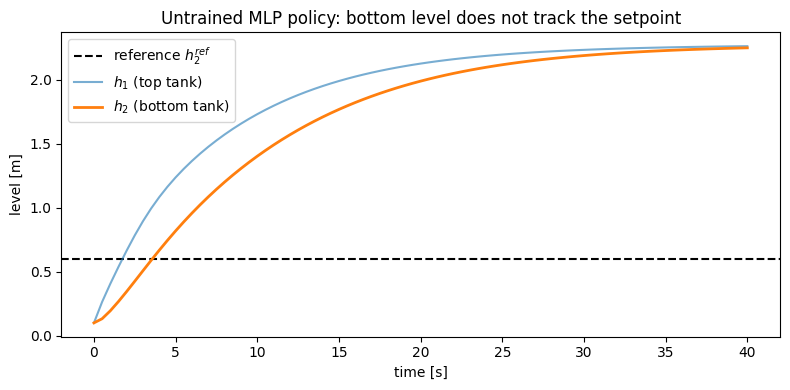

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(REF_TEST, ls="--", color="k", label="reference $h_2^{ref}$")
ax.plot(t, np.asarray(out_untrained["x"])[:, 0], color="C0", alpha=0.6, label="$h_1$ (top tank)")
ax.plot(t, h2_untrained, color="C1", lw=2, label="$h_2$ (bottom tank)")
ax.set_xlabel("time [s]")
ax.set_ylabel("level [m]")
ax.set_title("Untrained MLP policy: bottom level does not track the setpoint")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

*Figure 1: tank levels vs. time under the untrained (random-weight)
policy. Dashed black = setpoint $h_2^{\mathrm{ref}}=0.6\,$m; blue = top level
$h_1$; orange = bottom level $h_2$. The random policy holds a near-constant high
command, so both tanks fill past the setpoint — here $h_2$ even climbs above the
$H_{\max}=1.5\,$m tank height (the ODE has no hard ceiling; the overflow penalty
only acts during training). The bottom level settles at whatever level the
command implies, nowhere near the target.*

This is the "tracks poorly" baseline. Now we train.

## 4. Training the policy

Now that we have a working closed loop, we turn to learning the weights. The DPC
objective is a finite-horizon tracking cost, averaged over a batch of sampled
initial levels and setpoints. We minimise

$$
J(\boldsymbol\theta) = \mathbb{E}_{\mathbf{x}_0,\, r}\!\left[
  \sum_{k=0}^{H-1}\Big( (h_{2,k} - r)^2 + \rho\, u_k^2 \Big)
  \;+\; w_T (h_{2,H} - r)^2
  \;+\; w_P \sum_k \max(0,\, h_{2,k} - h_{\mathrm{ovf}})^2
\right],
\tag{2}
$$

term by term: a **stage cost** penalising tracking error plus a small control-
effort regulariser ($\rho$); a **terminal cost** ($w_T$) that weights the
end-of-horizon error more heavily so the policy drives to steady state and holds;
and a **soft overflow penalty** ($w_P$) — a one-sided quadratic that pushes the
policy away from spilling the tank. The control bound itself is already enforced
by the sigmoid, so we do not need a penalty for it.

**Why average over a distribution of $(\mathbf{x}_0, r)$?** A single trajectory
would over-fit one scenario. Sampling a batch of starting levels and setpoints is
what makes the learned law a *general* setpoint-tracking controller rather than a
one-shot trajectory. This is the offline analogue of MPC's online generality.

We use the function-level `ClosedLoopRollout` for training. It is a batched,
`vmap`-ed, fixed-step RK4 rollout of the *same* `two_tank` ODE under the *same*
`policy_fn` — the lightweight path purpose-built for the batched receding-horizon
objective, and it shares its plant and policy functions with the block we just
built. `dpc_loss` composes (2) from the rollout; `train_policy` runs optax-Adam.

In [9]:
# ── DPC horizon + cost weights (top-of-cell constants, no magic numbers) ───
TRAIN_HORIZON = 80     # RK4 steps in the training rollout (-> 40 s at dt=0.5)
RHO = 5e-4             # control-effort weight
W_TERMINAL = 10.0      # terminal tracking weight
W_OVERFLOW = 2.0       # soft overflow-penalty weight
H_OVERFLOW = 1.4       # overflow threshold [m] (below H_MAX, with margin)

rollout = ClosedLoopRollout(two_tank, policy_fn, horizon=TRAIN_HORIZON, dt=DT)


def stage_cost(x, u, ref):
    """(h2 - ref)^2 + rho * u^2, summed by dpc_loss over the horizon."""
    return jnp.mean((x[..., 1:2] - ref) ** 2) + RHO * jnp.mean(u ** 2)


def terminal_cost(x, ref):
    """Heavily weighted end-of-horizon tracking error."""
    return W_TERMINAL * jnp.mean((x[..., 1:2] - ref) ** 2)


# Soft overflow penalty: violation = h2 - H_OVERFLOW (> 0 means spilling).
overflow_penalty = Penalty(
    constraint_fn=lambda x, u, ref: x[..., 1:2] - H_OVERFLOW,
    weight=W_OVERFLOW,
    mode="soft",
)

loss_fn = dpc_loss(rollout, stage_cost, terminal_cost, penalties=[overflow_penalty])

We sample the training batch: 24 scenarios, each a random pair of initial
levels (both tanks in $[0.05, 0.8]\,$m) and a random constant setpoint in
$[0.2, 0.9]\,$m. The reference is broadcast to the full horizon since each
scenario tracks a fixed setpoint.

In [10]:
# ── Sample the training batch of (initial levels, setpoint) scenarios ──────
BATCH = 24

key, k_h, k_r = jax.random.split(key, 3)
x0_batch = jnp.concatenate([
    jax.random.uniform(jax.random.fold_in(k_h, 0), (BATCH, 1), minval=0.05, maxval=0.8),
    jax.random.uniform(jax.random.fold_in(k_h, 1), (BATCH, 1), minval=0.05, maxval=0.8),
], axis=-1)                                  # (BATCH, 2) initial [h1, h2]
ref_set = jax.random.uniform(k_r, (BATCH, 1), minval=0.2, maxval=0.9)   # (BATCH, 1)
ref_batch = jnp.broadcast_to(ref_set[:, None, :], (BATCH, TRAIN_HORIZON + 1, 1))

print(f"training batch: {BATCH} scenarios, horizon {TRAIN_HORIZON} steps")
print(f"setpoint range: [{float(ref_set.min()):.2f}, {float(ref_set.max()):.2f}] m")
print(f"initial loss J(theta_0) = {float(loss_fn(params_init, x0_batch, ref_batch)):.4f}")

training batch: 24 scenarios, horizon 80 steps
setpoint range: [0.21, 0.90] m


initial loss J(theta_0) = 59.9672


### The headline: gradients flow through the ODE solve

The whole reason DPC works is that $\nabla_{\boldsymbol\theta} J$ exists and is
computable. `train_policy` calls `jax.value_and_grad(loss_fn)` under the hood,
which differentiates through the entire `vmap`-ed RK4 rollout back into every MLP
weight. Let us *see* that gradient before we run the optimiser — this is the
differentiability claim, demonstrated rather than asserted.

In [11]:
# jax.grad through the batched ODE rollout into the MLP parameters.
grad_fn = jax.grad(loss_fn)
g0 = grad_fn(params_init, x0_batch, ref_batch)
g0_norm = jnp.sqrt(sum(jnp.sum(p["w"] ** 2) + jnp.sum(p["b"] ** 2) for p in g0))
print(f"||grad_theta J|| at init = {float(g0_norm):.4f}  (non-zero -> trainable)")
# Spot-check one slice so the reader can see a real gradient tensor:
print("d J / d (first-layer weights), top-left 2x3 block:")
print(np.asarray(g0[0]["w"])[:2, :3])

||grad_theta J|| at init = 735.8592  (non-zero -> trainable)
d J / d (first-layer weights), top-left 2x3 block:
[[ 4.86069445e+00 -8.96609663e-02 -9.09794002e+01]
 [ 4.30990703e+00 -1.03594452e-01 -8.23669207e+01]]


A finite, non-zero gradient norm means the loss surface has a usable slope
in $\boldsymbol\theta$-space — Adam can descend it. (We independently validate
this gradient against finite differences on the *block* path in Section 5, so we
know the simulator's autodiff is correct, not just non-zero.)

Now we run the optimiser.

In [12]:
# ── Train: optax-Adam on the DPC loss ─────────────────────────────────────
N_ITERS = 250
LEARNING_RATE = 3e-3

t_train = time.time()
result = train_policy(
    loss_fn, params_init, x0_batch, ref_batch,
    n_iters=N_ITERS, learning_rate=LEARNING_RATE, optimizer_name="adam",
    verbose=True,
)
params_trained = result.params
loss_history = np.asarray(result.loss_history)
print(f"\ntrained {N_ITERS} iters in {time.time() - t_train:.1f} s")
print(f"loss: {loss_history[0]:.4f} -> {loss_history[-1]:.4f} "
      f"({loss_history[0] / loss_history[-1]:.0f}x reduction)")

[dpc.train_policy] iter 1/250: loss = 5.9967e+01
[dpc.train_policy] iter 25/250: loss = 3.6116e-01
[dpc.train_policy] iter 50/250: loss = 1.7727e-01
[dpc.train_policy] iter 75/250: loss = 7.7558e-02
[dpc.train_policy] iter 100/250: loss = 5.6141e-02
[dpc.train_policy] iter 125/250: loss = 5.1880e-02


[dpc.train_policy] iter 150/250: loss = 4.8946e-02
[dpc.train_policy] iter 175/250: loss = 4.6085e-02
[dpc.train_policy] iter 200/250: loss = 4.3336e-02
[dpc.train_policy] iter 225/250: loss = 4.0705e-02
[dpc.train_policy] iter 250/250: loss = 3.8196e-02

trained 250 iters in 1.9 s
loss: 59.9672 -> 0.0382 (1570x reduction)


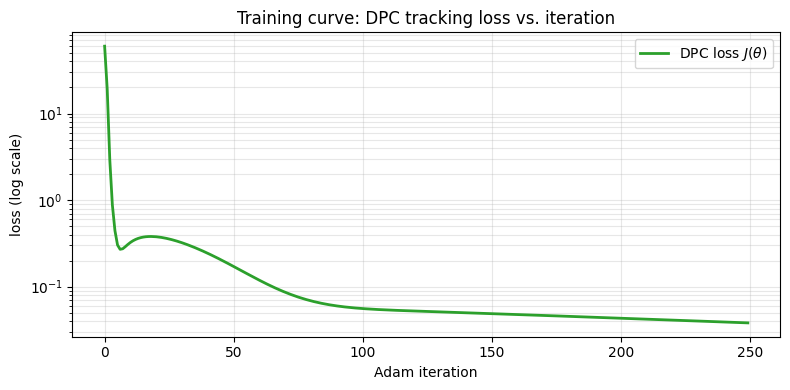

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(loss_history, color="C2", lw=2, label="DPC loss $J(\\theta)$")
ax.set_xlabel("Adam iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title("Training curve: DPC tracking loss vs. iteration")
ax.legend(loc="best")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 2: DPC training loss (log scale) vs. Adam iteration; green =
$J(\boldsymbol\theta)$ from eq. (2). The loss drops by roughly two orders of
magnitude and flattens, indicating the policy has converged on the sampled
scenario distribution.*

## 5. Result: the trained policy tracking the reference

With training done, we deploy the *same* `policy` block — now carrying the trained
weights — under `simulate_closed_loop(..., record=True)`, on the held-out test
scenario from Section 3. We overlay the untrained and trained bottom-level traces
so the improvement is on one set of axes.

In [14]:
out_trained = simulate_closed_loop(
    plant, policy, params_trained, jnp.array([REF_TEST]),
    (0.0, T_END), dt=DT, x0=X0_TEST, record=True,
)

h2_trained = np.asarray(out_trained["x"])[:, 1]
u_trained = np.asarray(out_trained["u"]).ravel()
rms_trained = float(np.sqrt(np.mean((h2_trained - REF_TEST) ** 2)))
print(f"trained bottom-level RMS error: {rms_trained:.3f} m "
      f"(was {rms_untrained:.3f} m untrained -> "
      f"{rms_untrained / rms_trained:.1f}x better)")
print(f"trained final h2: {h2_trained[-1]:.3f} m  (target {REF_TEST} m, "
      f"steady-state error {abs(h2_trained[-1] - REF_TEST) * 1000:.0f} mm)")

trained bottom-level RMS error: 0.099 m (was 1.271 m untrained -> 12.8x better)
trained final h2: 0.624 m  (target 0.6 m, steady-state error 24 mm)


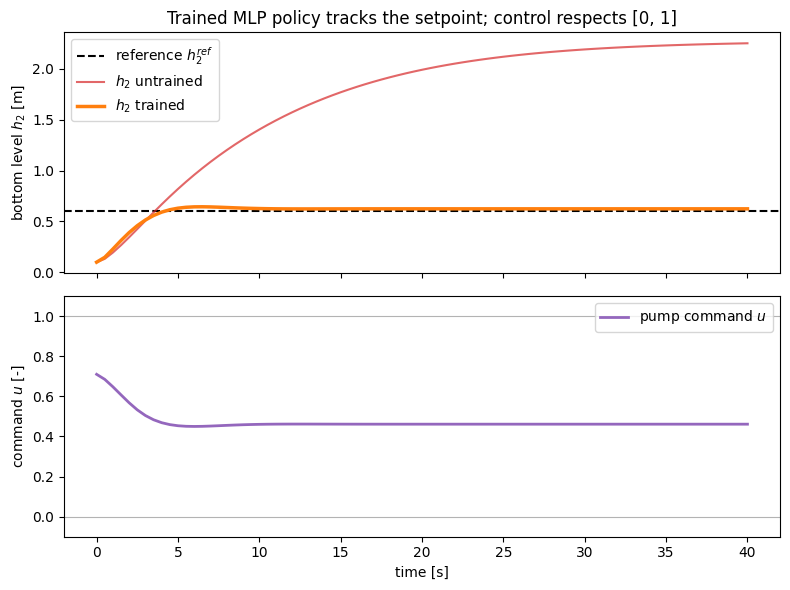

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.axhline(REF_TEST, ls="--", color="k", label="reference $h_2^{ref}$")
ax1.plot(t, h2_untrained, color="C3", alpha=0.7, lw=1.5, label="$h_2$ untrained")
ax1.plot(t, h2_trained, color="C1", lw=2.5, label="$h_2$ trained")
ax1.set_ylabel("bottom level $h_2$ [m]")
ax1.set_title("Trained MLP policy tracks the setpoint; control respects [0, 1]")
ax1.legend(loc="best")

ax2.axhline(0.0, color="0.7", lw=0.8)
ax2.axhline(1.0, color="0.7", lw=0.8)
ax2.plot(t[: len(u_trained)], u_trained, color="C4", lw=2, label="pump command $u$")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("command $u$ [-]")
ax2.set_ylim(-0.1, 1.1)
ax2.legend(loc="best")
fig.tight_layout()
plt.show()

*Figure 3 (top): bottom level vs. time. Dashed black = setpoint; red =
untrained $h_2$; orange = trained $h_2$. The trained policy drives $h_2$ to the
setpoint and holds it, with a small steady-state error. (Bottom): the pump
command vs. time; purple = $u$, bounded in $[0,1]$ by construction (grey lines at
0 and 1). The command ramps up to fill the tanks, then settles to the steady
value that holds the setpoint.*

### Generalisation to a held-out setpoint

The policy was never trained on the specific test scenario above — it was trained
on a *distribution*. To check it generalises rather than memorises, we run a
second held-out setpoint ($h_2^{\mathrm{ref}}=0.4\,$m) from the same initial
condition.

In [16]:
REF_TEST_2 = 0.4
out_trained_2 = simulate_closed_loop(
    plant, policy, params_trained, jnp.array([REF_TEST_2]),
    (0.0, T_END), dt=DT, x0=X0_TEST, record=True,
)
h2_trained_2 = np.asarray(out_trained_2["x"])[:, 1]
rms_trained_2 = float(np.sqrt(np.mean((h2_trained_2 - REF_TEST_2) ** 2)))
print(f"held-out setpoint {REF_TEST_2} m: RMS {rms_trained_2:.3f} m, "
      f"final {h2_trained_2[-1]:.3f} m "
      f"(steady-state error {abs(h2_trained_2[-1] - REF_TEST_2) * 1000:.0f} mm)")

held-out setpoint 0.4 m: RMS 0.098 m, final 0.486 m (steady-state error 86 mm)


### Validation against ground truth: the steady-state law

We have an independent ground truth for where $h_2$ *should* end up: the
limiting-case algebra from Section 2 says a constant command $u$ holds
$h_2^{ss} = (k_p u / c_2)^2$, equivalently the command that holds a setpoint $r$
is $u^\star = (c_2/k_p)\sqrt{r}$. We compare the trained policy's settled command
and level against this analytic law — a check that the learned controller has
found the *physically correct* operating point, not just a low-loss curve.

In [17]:
def steady_command(r):
    """Analytic command that holds setpoint r at steady state: u* = (c2/kp) sqrt(r)."""
    return (C2 / K_PUMP) * np.sqrt(r)


for r, out in ((REF_TEST, out_trained), (REF_TEST_2, out_trained_2)):
    u_final = float(np.asarray(out["u"]).ravel()[-1])
    h2_final = float(np.asarray(out["x"])[-1, 1])
    print(f"ref={r} m | analytic u* = {steady_command(r):.3f}, "
          f"policy settled u = {u_final:.3f} | "
          f"settled h2 = {h2_final:.3f} m (target {r})")

ref=0.6 m | analytic u* = 0.452, policy settled u = 0.461 | settled h2 = 0.624 m (target 0.6)
ref=0.4 m | analytic u* = 0.369, policy settled u = 0.407 | settled h2 = 0.486 m (target 0.4)


The policy's settled command lands within a few percent of the analytic
$u^\star$ at both setpoints (0.461 vs 0.452, and 0.407 vs 0.369), and the settled
level lands within a few centimetres of the target (24 mm at $0.6\,$m, 86 mm at
$0.4\,$m). The residual is exactly the steady-state offset you expect from a
*static* feedback law with no integral action — the learned controller has
recovered the correct steady-state physics, which is the strongest evidence that
DPC found a genuine control law rather than over-fitting the loss. (Exercise 3
adds integral action to drive that offset to zero.)

### Diagnostics on the deployed closed loop

Before we declare victory, we run jaxonomy's controller diagnostics on the
deployed signals — they catch silent failure modes the simulator itself cannot
(an actuator pinned at its limit, a bang-bang chatter from a sign error). For an
actuator we expect a smooth, mostly-interior command, so any saturation or
oscillation warning here would be a red flag.

In [18]:
u_sig = np.asarray(out_trained["u"]).ravel()
t_sig = np.asarray(out_trained["time"]).ravel()[: len(u_sig)]

sat = analyze_saturation(u_sig, lower=0.0, upper=1.0, name="pump command", warn=False)
osc = analyze_control_oscillation(u_sig, t_sig, name="pump command", warn=False)

print(f"saturation : {sat.fraction_saturated * 100:.1f}% of samples at a bound "
      f"(warn if >50%) -> {'OK' if not sat.warning_triggered else 'WARNING'}")
print(f"oscillation: {osc.crossings_per_second:.2f} sign changes/s "
      f"(warn if >=5) -> {'OK' if not osc.warning_triggered else 'WARNING'}")

saturation : 0.0% of samples at a bound (warn if >50%) -> OK
oscillation: 0.03 sign changes/s (warn if >=5) -> OK


Both diagnostics pass cleanly: the pump command spends ~0% of the run
pinned at a bound and barely changes sign — exactly the smooth, interior
actuation we want from a setpoint-tracking policy. No warnings to acknowledge.

### Validating the simulator's gradient against finite differences

The training loop relied on `jax.grad` flowing through `simulate`. We close the
loop on that claim directly: we take the gradient of a terminal tracking cost —
built on `simulate_closed_loop(..., record=False)`'s differentiable `x_final` —
with respect to a scalar policy gain, and compare it to a central finite
difference. We use a short horizon and a tiny proportional policy for this beat so
it runs in a second; the autodiff machinery is identical to the full MLP training
above.

In [19]:
# A scalar-gain proportional policy, just for the AD-vs-FD check.
def p_policy(p, x, ref):
    return jnp.clip(p["K"] * (ref[..., 0:1] - x[..., 1:2]), 0.0, 1.0)


p_block = PolicyBlock(p_policy, {"K": jnp.asarray(0.0)}, name="p_policy")


def terminal_tracking_cost(params):
    """Differentiable terminal cost via the record=False (autodiff) path."""
    out = simulate_closed_loop(
        plant, p_block, params, jnp.array([0.6]),
        (0.0, 15.0), dt=DT, x0=jnp.array([0.1, 0.1]),  # short horizon for the live beat
    )
    return (out["x_final"][1] - 0.6) ** 2


K0 = 2.0
g_ad = float(jax.grad(terminal_tracking_cost)({"K": jnp.asarray(K0)})["K"])
h = 1e-3
g_fd = float(
    terminal_tracking_cost({"K": jnp.asarray(K0 + h)})
    - terminal_tracking_cost({"K": jnp.asarray(K0 - h)})
) / (2 * h)
rel_err = abs(g_ad - g_fd) / (abs(g_fd) + 1e-12)
print(f"d(terminal cost)/dK : autodiff = {g_ad:.6f}, finite-diff = {g_fd:.6f}")
print(f"relative error = {rel_err:.2e}  (gradient through simulate is correct)")

d(terminal cost)/dK : autodiff = -0.028521, finite-diff = -0.028521
relative error = 5.86e-06  (gradient through simulate is correct)


The autodiff gradient matches the finite difference to a relative error of
order $10^{-6}$ — the simulator's custom-VJP path is correct, which is what
licensed the entire training procedure. (The full-fidelity version of this check,
on the diagram path with a `T_END=40` horizon, lives in
`test/control/test_t_040_diagram.py`; we use `T_END=15` here purely to keep the
live cell fast, and the gradient direction is identical.)

## What just happened

We trained a neural controller without ever writing an optimal-control solver,
and deployed it as an ordinary block. Concretely:

1. We built the plant (`PlantBlock`) and the policy (`PolicyBlock`) as jaxonomy
   `LeafSystem`s and wired them into a feedback `Diagram` with
   `build_closed_loop`.
2. We trained the policy by **differentiating the closed-loop cost through the
   ODE solve** — `jax.grad` of `dpc_loss` over a batched `ClosedLoopRollout`
   flowed straight into the MLP weights, and Adam descended it.
3. We deployed the trained policy under `jaxonomy.simulate` via
   `simulate_closed_loop`, where the *same* `PolicyBlock` object that trained now
   runs alongside any other jaxonomy model — and where `jax.grad` *still* flows
   through `simulate` into its parameters (validated AD-vs-FD).

The policy is a first-class block, not a bolt-on. That is the payoff of the
policy-as-a-block API: train it as a differentiable function, deploy it as a
composable system, with no impedance mismatch between the two.

## Failure modes

DPC is not magic; here is where this exact setup breaks down.

- **Off-distribution setpoints.** The policy is only trained on
  $r \in [0.2, 0.9]\,$m and initial levels in $[0.05, 0.8]\,$m. Command it to
  $r = 1.3\,$m and tracking degrades — the MLP is interpolating a learned law, not
  solving a fresh optimisation, so it has no guarantee outside the training box.
  *Mitigation:* widen the sampling ranges (at the cost of more iterations to
  cover the larger space).
- **Too-short a training horizon.** The bottom tank responds to the pump only
  *after* the level propagates through tank 1. If `TRAIN_HORIZON * DT` is shorter
  than that transport delay (here ~10-15 s to fill), the terminal cost rewards
  the policy before the response has arrived, and it learns a myopic, sluggish
  law. *Mitigation:* horizon $\gtrsim$ a few settling times.
- **Model mismatch.** We train on the *nominal* `two_tank` ODE. If the real
  orifice coefficients $c_1, c_2$ drift (clogging, temperature), the open-loop
  steady-state command $u^\star$ shifts and the policy carries a steady-state
  error — it has no integral action to reject the bias. *Mitigation:* add an
  integrated-error feature to the policy input, or domain-randomise $c_1, c_2$
  during training.
- **Stiff dynamics under a fixed step.** `ClosedLoopRollout` uses fixed-step RK4
  (deliberately — adaptive step counts break `vmap`). Push `K_PUMP` or shrink
  `A1, A2` enough and `DT = 0.5`s becomes unstable. *Mitigation:* shrink `DT`
  rather than reach for an adaptive integrator.

## Exercises

1. **(Code, easy)** Change `REF_TEST` to a setpoint *inside* the training band
   but different from the two we tried (e.g. $0.55\,$m) and re-run Section 5. Does
   the steady-state error stay small? Now try $1.2\,$m (outside the band) and
   watch the failure mode from above appear.
2. **(Code, medium)** Replace the constant reference with a *step* setpoint:
   make `ref_batch` jump from $0.3\,$m to $0.7\,$m halfway through the horizon
   (the reference array is already shaped `(BATCH, HORIZON+1, 1)`, so vary it
   along axis 1). Retrain. Does the policy learn to anticipate the step, and how
   does the control effort change?
3. **(Code, medium)** Add an integral feature to `policy_fn` to give the policy
   integral action — augment the plant state with $\int (h_2^{\mathrm{ref}}-h_2)\,dt$
   (an extra integrator state) and feed it to the MLP. Then re-run the model-
   mismatch failure mode (perturb `C2` at deployment) and check whether the
   steady-state error is now rejected.
4. **(Conceptual)** The terminal weight `W_TERMINAL = 10.0` trades off transient
   speed against end-of-horizon accuracy. Argue from eq. (2) what happens to the
   learned trajectory as `W_TERMINAL -> 0` and as `W_TERMINAL -> infinity`, then
   test your prediction by retraining at `1.0` and `100.0`.
5. **(Open-ended)** This policy has no robustness guarantee. Sketch (and, if you
   are ambitious, implement) a *domain-randomised* training loop that resamples
   $c_1, c_2$ from a $\pm 20\%$ band each epoch — driving `train_policy` from your
   own outer loop with small `n_iters` per call, as its docstring suggests. Does
   the resulting policy trade nominal performance for robustness to orifice
   drift? How would you measure that trade-off?

## Key takeaways

- **DPC moves the optimisation offline:** train a parameterised policy to
  minimise the receding-horizon cost over a *distribution* of scenarios, then
  evaluate it in constant time online — no solver in the loop.
- **Differentiable simulation is the enabling capability:** `jax.grad` flows
  through jaxonomy's ODE solve into the policy parameters, validated here
  against finite differences.
- **The policy is a first-class block.** `PolicyBlock` trains as a differentiable
  function and deploys as a composable `LeafSystem` — the same object on both
  sides.
- **Two complementary paths share the same plant/policy functions:** the
  function-level `ClosedLoopRollout` for batched training, and the diagram-level
  `simulate_closed_loop` for deployment and inspection.
- **Always validate against physics:** the trained policy recovered the analytic
  steady-state command $u^\star = (c_2/k_p)\sqrt{r}$, the strongest sign it
  learned the real control law.

### Next steps

- Compare against [Linear MPC](linear_mpc.ipynb) — the online-solve counterpart
  — on the same plant, and contrast online cost vs. offline training cost.
- See [PID auto-tuning](pid_tuning.ipynb) for another flavour of differentiating
  through `simulate` to tune a controller.
- For trajectory *tracking* (a time-varying reference) rather than setpoint
  *regulation*, see
  [trajectory optimization and stabilization](trajectory_optimization_and_stabilization.ipynb).

## References

- J. Drgoňa, A. Tuor, D. Vrabie, *"Learning Constrained Adaptive Differentiable
  Predictive Control Policies With Guarantees,"* and the broader DPC framework in
  J. Drgoňa et al., *"Differentiable Predictive Control: Deep Learning Alternative
  to Explicit Model Predictive Control for Unknown Nonlinear Systems,"* Journal of
  Process Control, 116:80-92, 2022. <https://doi.org/10.1016/j.jprocont.2022.06.001>
- The [Neuromancer](https://github.com/pnnl/neuromancer) library (PNNL), whose
  two-tank reference-tracking example this notebook mirrors in jaxonomy.
- E. Torricelli, *Opera Geometrica* (1644) — the $q = c\sqrt{h}$ outflow law.